# Fairness in AI: Chest X-Ray Classification Project

## Introduction

This project studies fairness in binary chest X-ray classification on a subset of the NIH Chest X-ray dataset provided in class.

The image model used in this project is a ResNet18 baseline (`train_classifieur.py`) trained on image folders (`train/`, `valid/`) and linked metadata (`metadata.csv`).

The key question is whether mitigation methods improve fairness across sensitive groups (gender and age) while preserving predictive performance, especially balanced accuracy.

**Notebook structure:**
1. Environment and imports
2. Fast bias analysis on metadata
3. Comparison of training with weights vs without weights
4. Pre-processing and post-processing mitigation analysis
5. Discussion and conclusion

## 0. Environment and Setup

Folder assumptions:
- Project/Al_Masri_Reina/train
- Project/Al_Masri_Reina/valid
- Project/Al_Masri_Reina/metadata.csv
- Project/train_classifieur.py


In [3]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.metrics import balanced_accuracy_score, accuracy_score
from aif360.sklearn.metrics import *

from train_classifieur import train_classifier, pred_classifier

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'
pip install 'aif360[OptimalTransport]'


In [4]:
# setup
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

# paths and directories
DATA_DIR = './Al_Masri_Reina/'
CSV_PATH = os.path.join(DATA_DIR, 'metadata.csv')
LOG_ROOT = './expe_log'

DATA_DIR, CSV_PATH, LOG_ROOT

('./Al_Masri_Reina/', './Al_Masri_Reina/metadata.csv', './expe_log')

In [5]:
# TD get_metrics function
def get_metrics(
    y_true,
    y_pred=None,
    prot_attr=None,
    priv_group=1,
    pos_label=1,
    sample_weight=None,
    ):
    group_metrics = {}
    group_metrics['base_rate_truth'] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics['statistical_parity_difference'] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics['disparate_impact_ratio'] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    if not y_pred is None:
        group_metrics['base_rate_preds'] = base_rate(
        y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics['equal_opportunity_difference'] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics['average_odds_difference'] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        if len(set(y_pred))>1:
            group_metrics['conditional_demographic_disparity'] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
            )
        else:
            group_metrics['conditional_demographic_disparity'] =None
        group_metrics['smoothed_edf'] = smoothed_edf(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics['df_bias_amplification'] = df_bias_amplification(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics['balanced_accuracy_score'] = balanced_accuracy_score(
        y_true=y_true, y_pred=y_pred, sample_weight=sample_weight
        )
    return group_metrics


In [6]:
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
display(df.head(3))
print('Columns:', list(df.columns))

Shape: (5389, 15)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000020_000.png,Pleural_Thickening,0,20,53,M,PA,2978,2991,0.143,0.143,NaN,train,malade,1
1,00000020_001.png,Fibrosis|Infiltration,1,20,47,M,PA,2992,2991,0.143,0.143,NaN,train,malade,1
2,00000020_002.png,Fibrosis|Infiltration|Pleural_Thickening,2,20,48,M,PA,2414,2991,0.143,0.143,NaN,train,malade,1


Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'train_valid', 'label', 'WEIGHTS']


## 1. Fast Bias Analysis

*This section is intentionally short: just enough evidence to identify the main imbalance and bias signals before modeling.*

**Step 1: Minimal data checks**

*Quick sanity check: dataset size, missing values, and class balance.*

In [37]:
# quick shape check
print(f'Shape: {df.shape}')

# quick missing-values check
print(f'Total missing values: {int(df.isna().sum().sum())}')

Shape: (5389, 19)
Total missing values: 5390


In [38]:
# quick class balance check
print('Label distribution:')
display(df['label'].value_counts(dropna=False))

Label distribution:


label
sain      2914
malade    2475
Name: count, dtype: int64

In [30]:
# create binary target used for fairness metrics
df['has_finding'] = (df['label'] == 'malade').astype(int)

# create binary sensitive attributes (TD convention)
df['gender'] = (df['Patient Gender'] == 'M').astype(int)
df['age_binary'] = (df['Patient Age'] >= 50).astype(int)

# create age groups for concise subgroup analysis
df['age_group'] = pd.cut(df['Patient Age'], bins=[0, 30, 50, 70, 110], labels=['<30', '30-50', '50-70', '70+'])

In [31]:
# quick subgroup distributions
print('Gender distribution:')
display(df['Patient Gender'].value_counts(dropna=False))

print('Age group distribution:')
display(df['age_group'].value_counts(dropna=False).sort_index())

Gender distribution:


Patient Gender
M    2928
F    2461
Name: count, dtype: int64

Age group distribution:


age_group
<30       983
30-50    1729
50-70    2372
70+       304
NaN         1
Name: count, dtype: int64

**Step 2: Sensitive groups + quick rates**

*Convention: privileged groups are Male and Age >= 50.*

*We check bivariate rates to see if outcome gaps already exist before modeling.*

In [39]:
# compute label rate by gender
gender_ctab = pd.crosstab(df['Patient Gender'], df['label'], normalize='index')

display(gender_ctab)

label,malade,sain
Patient Gender,,
F,0.481105,0.518895
M,0.440915,0.559085


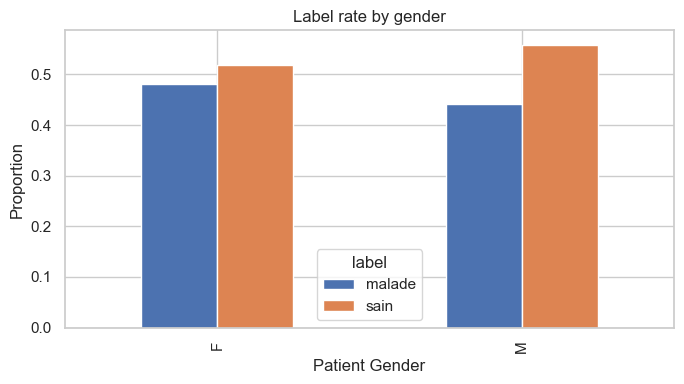

In [33]:
# visualize gender rate gap
gender_ctab.plot(kind='bar', figsize=(7, 4), title='Label rate by gender')
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()

In [34]:
# compute label rate by age group
age_ctab = pd.crosstab(df['age_group'], df['label'], normalize='index')
display(age_ctab.round(3))

# quick significance test for age-group gap
cont_age = pd.crosstab(df['age_group'], df['has_finding'])
chi2_age, p_age, _, _ = chi2_contingency(cont_age)
print(f'Chi-squared p-value (Age group x finding): {p_age:.4e}')

label,malade,sain
age_group,,
<30,0.409,0.591
30-50,0.388,0.612
50-70,0.516,0.484
70+,0.582,0.418


Chi-squared p-value (Age group x finding): 1.3659e-20


In [35]:
# compute fairness metrics on ground-truth labels
gender_truth_metrics = get_metrics(
    y_true=df['has_finding'],
    y_pred=df['has_finding'],
    prot_attr=df['gender'],
    priv_group=1,
    pos_label=1
)

age_truth_metrics = get_metrics(
    y_true=df['has_finding'],
    y_pred=df['has_finding'],
    prot_attr=df['age_binary'],
    priv_group=1,
    pos_label=1
)

**Step 3: Fairness baseline**

*We now report TD fairness metrics to set the baseline before weighted/unweighted classifier training.*

In [40]:
# fairness baseline
print('Gender fairness (privileged = Male):')
print(f"SPD: {gender_truth_metrics['statistical_parity_difference']:.4f}")
print(f"DIR: {gender_truth_metrics['disparate_impact_ratio']:.4f}")

print('\nAge fairness (privileged = >=50):')
print(f"SPD: {age_truth_metrics['statistical_parity_difference']:.4f}")
print(f"DIR: {age_truth_metrics['disparate_impact_ratio']:.4f}")

Gender fairness (privileged = Male):
SPD: 0.0402
DIR: 1.0912

Age fairness (privileged = >=50):
SPD: -0.1233
DIR: 0.7626


*Fast takeaway: age bias is the main signal. Next step is to train the provided classifier (`train_classifieur.py`) with and without weights and compare performance + fairness.*

## 2. With Weights vs Without Weights

*Classifier used here is the provided one: `train_classifieur.py` (`train_classifier` + `pred_classifier`).*

The goal is a direct comparison between weighted and unweighted training with the same pipeline.

*For a quick check we use `max_epochs=1`; for the final report we increase it (10-25).*

In [7]:
df_exp = df.copy()
df_exp['WEIGHTS_NO'] = 1.0

csv_compare = f"{LOG_ROOT}/metadata_compare_weights.csv"
df_exp.to_csv(csv_compare, index=False)

MAX_EPOCHS = 1
ts = datetime.now().strftime('%Y_%m_%d_%H_%M_%S')
logdir_w = f"{LOG_ROOT}/with_weights_{ts}"
logdir_nw = f"{LOG_ROOT}/without_weights_{ts}"

In [ ]:
ckpt_path_w, ckpt_score_w = train_classifier(
    logdir=logdir_w,
    datadir=DATA_DIR,
    weights_col='WEIGHTS',
    csv=csv_compare,
    max_epochs=MAX_EPOCHS,
 )

ckpt_path_w, ckpt_score_w

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


./expe_log/metadata_compare_weights.csv ./expe_log/with_weights_2026_03_20_11_13_37/csv_in_WEIGHTS.csv
num_workers set to : 8
num_workers set to : 8
batch_size set to : 16


/Users/reina/Desktop/Semestre 6/Fairness IA/Project/.venv/lib/python3.14/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/reina/Desktop/Semestre 6/Fairness IA/Project/expe_log/with_weights_2026_03_20_11_13_37 exists and is not empty.
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type                  | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model | ResNet                | 11.2 M | train | 0    
1 | cm    | BinaryConfusionMatrix | 0      | train | 0    
----------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.710    Total estimated model params size (MB)
69        Modules in train mode
0         Modules in eval mode
0         Total Flops


Start training
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/reina/Desktop/Semestre 6/Fairness IA/Project/.venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


/Users/reina/Desktop/Semestre 6/Fairness IA/Project/.venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Epoch 0:  25%|██▌       | 63/249 [01:46<05:14,  0.59it/s, v_num=0]

In [ ]:
pred_classifier(
    datadir=DATA_DIR,
    csv_in=csv_compare,
    csv_out=f'{logdir_w}/preds.csv',
    ckpt_path=ckpt_path_w,
 )

df_w = pd.read_csv(f'{logdir_w}/preds.csv')
df_w.head(3)

In [ ]:
ckpt_path_nw, ckpt_score_nw = train_classifier(
    logdir=logdir_nw,
    datadir=DATA_DIR,
    weights_col='WEIGHTS_NO',
    csv=csv_compare,
    max_epochs=MAX_EPOCHS,
 )

ckpt_path_nw, ckpt_score_nw

In [ ]:
pred_classifier(
    datadir=DATA_DIR,
    csv_in=csv_compare,
    csv_out=f'{logdir_nw}/preds.csv',
    ckpt_path=ckpt_path_nw,
 )

df_nw = pd.read_csv(f'{logdir_nw}/preds.csv')
df_nw.head(3)

In [ ]:
def run_metrics(df_pred):
    d = df_pred.copy()
    d['gender'] = (d['Patient Gender'] == 'M').astype(int)
    d['age_binary'] = (d['Patient Age'] >= 50).astype(int)

    g = get_metrics(
        y_true=d['labels'], y_pred=d['preds'],
        prot_attr=d['gender'], priv_group=1, pos_label='malade'
    )
    a = get_metrics(
        y_true=d['labels'], y_pred=d['preds'],
        prot_attr=d['age_binary'], priv_group=1, pos_label='malade'
    )
    return {
        'balanced_accuracy': balanced_accuracy_score(d['labels'], d['preds']),
        'accuracy': accuracy_score(d['labels'], d['preds']),
        'gender_SPD': g['statistical_parity_difference'],
        'gender_DIR': g['disparate_impact_ratio'],
        'age_SPD': a['statistical_parity_difference'],
        'age_DIR': a['disparate_impact_ratio'],
    }

In [ ]:
m_w = run_metrics(df_w)
m_nw = run_metrics(df_nw)

comparison_runs = pd.DataFrame([
    {'run': 'with_weights', **m_w},
    {'run': 'without_weights', **m_nw},
])

comparison_runs.round(4)

In [ ]:
## 3. Next Coding Steps

### A. Preparation et analyse des donnees (/3)
# - Keep this section short and factual (tables + 1-2 figures + short interpretation).
# - Show class imbalance, sensitive-group distributions, and one crossed analysis.

### B. Pre-processing and fairness metrics (/3)
# - Extend weighting strategies beyond baseline WEIGHTS (for example class-balanced or subgroup-balanced).
# - Compare each strategy against the no-weight baseline from Section 2.
# - Report balanced accuracy and fairness metrics in one table.

### C. Post-processing and fairness metrics (/5)
# - Apply at least 2 post-processing methods from TD.
#- Compare post-processing alone, pre-processing alone, and pre+post combinations.

### D. Analyse et comprehension (/3)
# - Explain trade-offs between fairness and performance with concrete numbers.

### E. Soin (/4)
# - Keep short markdown interpretations after each result block.

### F. Conclusion (/1)
# - Summarize best compromise model and remaining limitations.